# Raport — LABxx  
## Eksperiment kompjuterik: Koha e ekzekutimit dhe ndryshueshmëria

**Lënda:** Hyrje në Laborator  
**Kodi i laboratorit:** `LABxx`  
**Titulli:** `Studimi i kohës së ekzekutimit të një algoritmi.`
**Studenti / Studentja:** `Marie Curie`  
**Grupi:** `1`  
**Data e zhvillimit të laboratorit:** `01-04-2026`  
**Data e dorëzimit:** `08-04-2026`  
**Pedagogu:** ` ek `


---

## 1. Qëllimi i ushtrimit

Qëllimi i këtij eksperimenti është të studiohet se si ndryshon koha e ekzekutimit të një algoritmi me rritjen e madhësisë së inputit, si dhe të vlerësohet ndryshueshmëria e kohës së ekzekutimit për të njëjtën detyrë të përsëritur disa herë.


## 2. Teoria

Në eksperimentet kompjuterike nuk mjafton vetëm të matet një herë koha e ekzekutimit.  
Edhe kur kodi mbetet i pandryshuar, koha mund të luhatet për shkak të:
- planifikimit të proceseve nga sistemi operativ,
- cache-it dhe memories,
- proceseve në background,
- overhead-it të vetë matjes.

Prandaj, për secilën madhësi hyrjeje duhen përsëritur disa here matjet. Kështu mund të analizohet njëkohësisht:
- **trendi mesatar** i kohës me rritjen e $n$,
- **shpërndarja** e kohës për një $n$ të fiksuar.


## 3. Aparatura / software

- Python 3
- `numpy`
- `pandas`
- `matplotlib`

Të dhënat ndodhen në:

`data/koha_ekzekutimit_algoritmi.csv`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)

df = pd.read_csv("data/koha_ekzekutimit_algoritmi.csv")
df.head()


,n,perseritja,koha_ms
0,500,1,0.822900
1,500,2,0.393459
2,500,3,1.698128
3,500,4,1.977687
4,500,5,0.388460


## 4. Procedura eksperimentale / matëse

Për disa vlera të madhësisë së hyrjes $n$, koha e ekzekutimit u mat shumë herë.  
Qëllimi është të shihet:
1. si rritet koha mesatare me $n$,
2. sa e madhe është luhatja nga një ekzekutim në tjetrin.

Kjo qasje është thelbësore në studimet e performancës, sepse koha e ekzekutimit duhet trajtuar si një madhësi që ka shpërndarje statistikore.


## 5. Të dhënat e papërpunuara


In [2]:
df.head(15)


,n,perseritja,koha_ms
0,500,1,0.822900
1,500,2,0.393459
2,500,3,1.698128
3,500,4,1.977687
4,500,5,0.388460
5,500,6,0.308788
6,500,7,1.035953
7,500,8,0.531150
8,500,9,0.952271
9,500,10,0.794187


## 6. Përpunimi paraprak i të dhënave

Llogarisim statistikat përmbledhëse sipas madhësisë së hyrjes:
- mesataren,
- devijimin standard,
- minimumin,
- maksimumin,
- medianën,
- numrin e përsëritjeve.


In [3]:
permbledhje = df.groupby("n")["koha_ms"].agg(["mean", "std", "min", "max", "median", "count"])
permbledhje


,mean,std,min,max,median,count
n,,,,,,
500,1.271759,0.959453,0.308788,5.457441,1.190401,30
1000,2.312019,0.680069,1.041921,3.673211,2.278134,30
2000,5.537181,1.385455,4.241226,11.605934,5.159805,30
4000,11.323108,0.904723,9.769322,13.501132,11.335807,30
8000,25.325965,1.580125,22.840979,31.546588,25.025936,30
16000,53.722260,0.686541,51.978021,55.014461,53.875162,30


## 7. Analiza e të dhënave


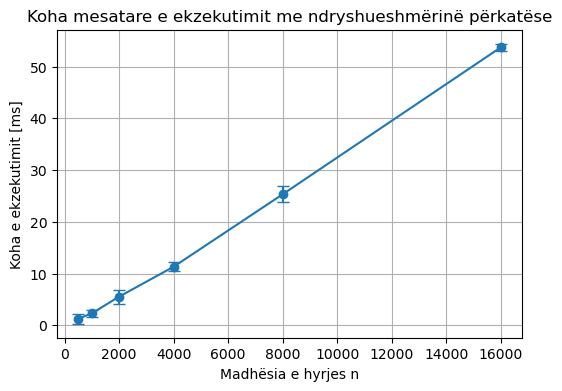

In [4]:
plt.errorbar(permbledhje.index, permbledhje["mean"], yerr=permbledhje["std"], fmt="o-", capsize=4)
plt.xlabel("Madhësia e hyrjes n")
plt.ylabel("Koha e ekzekutimit [ms]")
plt.title("Koha mesatare e ekzekutimit me ndryshueshmërinë përkatëse")
plt.grid(True)
plt.show()


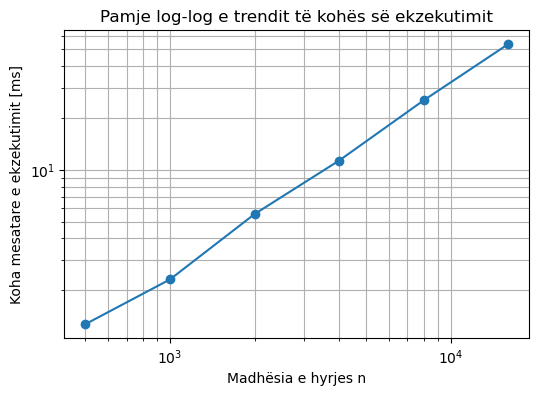

In [5]:
plt.loglog(permbledhje.index, permbledhje["mean"], "o-")
plt.xlabel("Madhësia e hyrjes n")
plt.ylabel("Koha mesatare e ekzekutimit [ms]")
plt.title("Pamje log-log e trendit të kohës së ekzekutimit")
plt.grid(True, which="both")
plt.show()


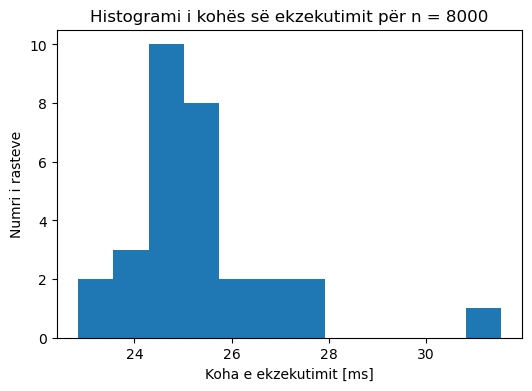

count    30.000000
mean     25.325965
std       1.580125
min      22.840979
25%      24.597507
50%      25.025936
75%      25.592819
max      31.546588
Name: koha_ms, dtype: float64

In [7]:
n0 = 8000
nen_grupi = df[df["n"] == n0]["koha_ms"]

plt.hist(nen_grupi, bins=12)
plt.xlabel("Koha e ekzekutimit [ms]")
plt.ylabel("Numri i rasteve")
plt.title(f"Histogrami i kohës së ekzekutimit për n = {n0}")
#plt.grid(True)
plt.show()

nen_grupi.describe()


## 8. Pasiguritë dhe burimet e gabimeve

Në këtë eksperiment, variacioni i kohës së ekzekutimit nuk është vetëm “gabim matjeje”, por pjesë e vetë sjelljes së sistemit kompjuterik.  
Burime tipike janë:
- procese të tjera aktive në sistem,
- luhatje në planifikimin e proceseve,
- cache miss / memory effects,
- ndërprerje dhe aktivitet i OS,
- overhead i funksionit të matjes.

Prandaj, interpretimi duhet të dallojë:
- rritjen mesatare të kohës me $n$,
- shpërndarjen e kohës për një $n$ të caktuar.


## 9. Diskutimi

Nga grafiku i mesatareve shihet se koha e ekzekutimit rritet me rritjen e madhësisë së hyrjes.  
Nga ana tjetër, histogrami për një vlerë të vetme të $n$ tregon se koha nuk është fikse, por ka luhatje nga një ekzekutim në tjetrin.

Ky është një shembull i mirë se si një eksperiment kompjuterik duhet trajtuar njëkohësisht si:
- studim i trendit algoritmik,
- studim statistik i ndryshueshmërisë së ekzekutimit.


## 10. Përfundimi

Analiza tregon se performanca e një algoritmi nuk përshkruhet plotësisht vetëm nga një kohë e vetme ekzekutimi.  
Duhet të studiohen si:
- varësia nga madhësia e hyrjes,
- ashtu edhe luhatjet statistikore të kohës së ekzekutimit.
